In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from sympy import *


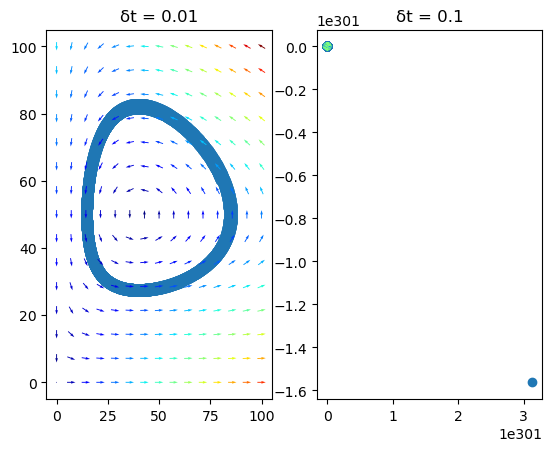

In [ ]:
def lotka_volterra(t, z, coefs=None):
    if coefs is None:
        coefs = [0.5, 0.01, 0.2, 0.005]
    x, y = z
    a, b, c, d = coefs
    return [a * x - b * x * y, -c * y + d * x * y]


def generate_mesh_2d(xy_range, n_points):
    X, Y = np.meshgrid(
        np.linspace(xy_range[0], xy_range[1], n_points),
        np.linspace(xy_range[2], xy_range[3], n_points),
    )
    return X, Y


def vector_field(X, Y, U, V, xy_range, ax):
    # Norm of the growth rate
    M = np.hypot(U, V)  # equivalent to np.sqrt(U**2 + V**2)
    M[M == 0] = 1  # Avoid zero division errors
    U /= M  # Normalize each vector_field
    V /= M

    ax.quiver(X, Y, U, V, M, pivot="mid", cmap=plt.cm.jet)


def euler2(xy_init, step_size, period):
    X, Y = xy_init
    x, y = [], []
    time = []
    for i in range(period):
        x.append(X)
        y.append(Y)
        # 每次 + 步长 * 导数（上一对 x,y）
        z = [x[-1], y[-1]]
        X += step_size * lotka_volterra(t=0, z=z)[0]
        Y += step_size * lotka_volterra(t=0, z=z)[1]
        time.append(step_size * i)
    return x, y, time


xy_range = [0, 100, 0, 100]
n_points = 15

# create a grid
X, Y = generate_mesh_2d(xy_range, n_points)
# compute growth rate on the grid
U, V = lotka_volterra(t=0, z=[X, Y])

_, axes = plt.subplots(1, 2)

step_sizes = [0.01, 0.1]
xy_init = [80, 60]
period = 10000

for ind, step in enumerate(step_sizes):
    x, y, time = euler2(xy_init, step, period)
    axes[ind].scatter(x, y)
    vector_field(X, Y, U, V, xy_range, axes[ind])
    axes[ind].set(title=f"δt = {step}")

[Text(0.5, 0, 'Time'),
 Text(0, 0.5, 'X'),
 Text(0.5, 1.0, 'The Logistics Equation')]

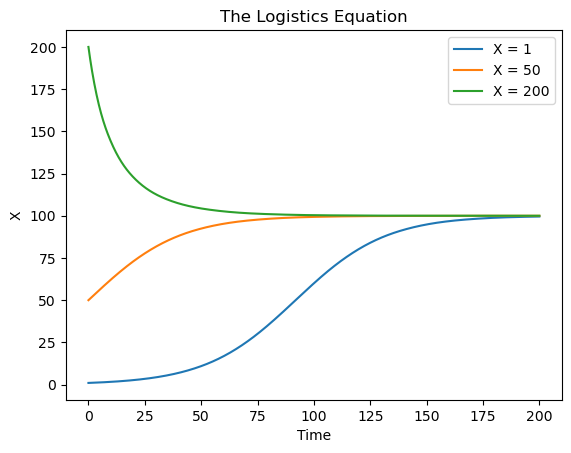

In [ ]:
def lotka_volterra(t, X):
    return 0.05 * X * (1 - X / 100)


x_inits = [1, 50, 200]
t_span = [0, 200]
t = np.linspace(t_span[0], t_span[1], 1000)

_, ax = plt.subplots()

for x_init in x_inits:
    sol = solve_ivp(lotka_volterra, t_span, [x_init], dense_output=True)
    X = sol.sol(t).T
    ax.plot(t, X, label=f"X = {x_init}")

ax.legend()
ax.set(xlabel="Time", ylabel="X", title="The Logistics Equation")

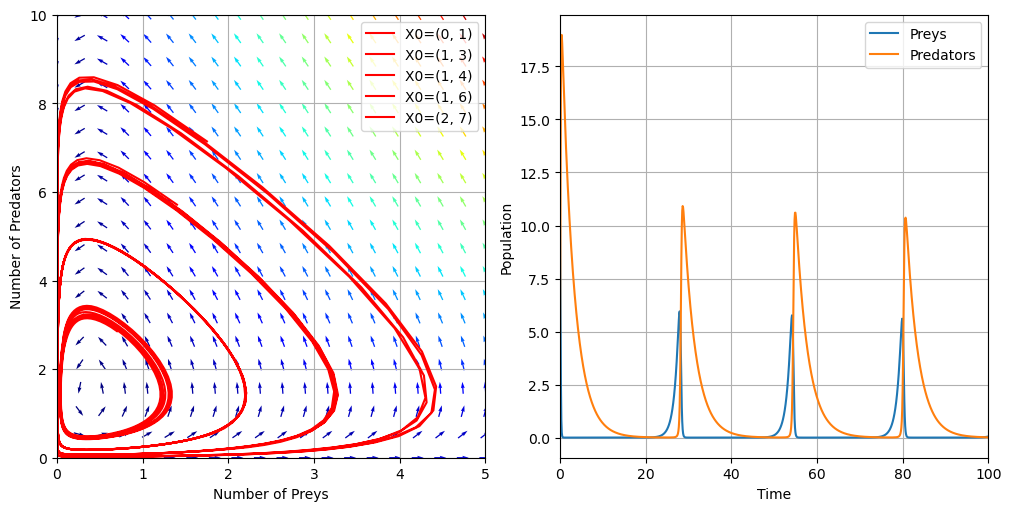

In [12]:
def lotka_volterra(t, z, coefs):
    x, y = z
    a, b, c, d = coefs
    return [a * x - b * x * y, -c * y + d * x * y]


def generate_mesh_2d(xy_range, n_points):
    X, Y = np.meshgrid(
        np.linspace(xy_range[0], xy_range[1], n_points),
        np.linspace(xy_range[2], xy_range[3], n_points),
    )
    return X, Y


def vector_field(X, Y, U, V, ax):
    M = np.hypot(U, V)  # Norm of the growth rate
    M[M == 0] = 1  # Avoid zero division errors
    U /= M  # Normalize each vector_field
    V /= M
    ax.quiver(X, Y, U, V, M, pivot="mid", cmap=plt.cm.jet)


_, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=1)

xy_range = [0, 5, 0, 10]
n_points = 20
coefs = [1, 0.7, 0.35, 1]
a, b, c, d = coefs

# create a grid
X, Y = generate_mesh_2d(xy_range, n_points)
# compute growth rate on the grid
U, V = lotka_volterra(t=0, z=[X, Y], coefs=coefs)
vector_field(X, Y, U, V, ax)

X_R = [c / d, a / b]
t_span = [0, 100]

vals = np.linspace(1, 5, 5)
v_colors = plt.cm.autumn_r(vals)
t = np.linspace(t_span[0], t_span[1], 1000)

for v, col in zip(vals, v_colors):
    z = v * np.array(X_R)
    sol = solve_ivp(lotka_volterra, t_span, z, args=([coefs]), dense_output=True)
    X = sol.sol(t).T
    preys, predators = X[:, 0], X[:, 1]
    ax.plot(preys, predators, color=col, label=f"X0=({z[0]:.0f}, {z[1]:.0f})")

ax.set(
    xlabel="Number of Preys",
    ylabel="Number of Predators",
    xlim=(xy_range[0], xy_range[1]),
    ylim=(xy_range[2], xy_range[3]),
)
ax.grid()
ax.legend()

# curves
X0 = [10, 5]
sol2 = solve_ivp(lotka_volterra, t_span, X0, args=([coefs]), dense_output=True)

z = sol2.sol(t).T

ax2.plot(t, z)
ax2.set(xlabel="Time", ylabel="Population", xlim=(t_span[0], t_span[1]))
ax2.grid()
ax2.legend(["Preys", "Predators"])

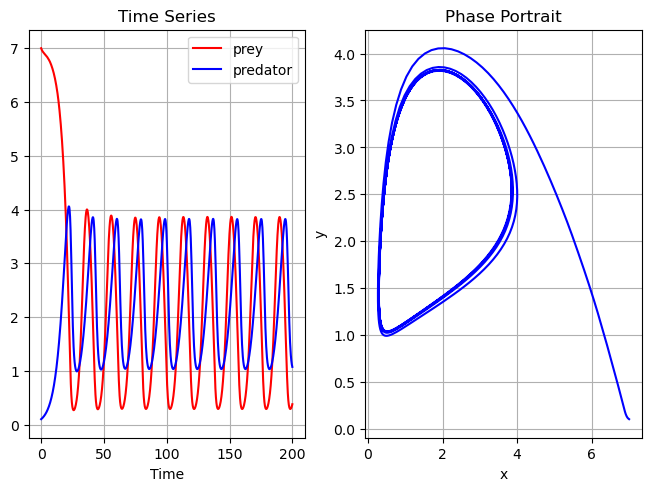

In [4]:
def Holling_Tanner(t, z):
    x, y = z
    u = x * (1 - x / 7) - 6 / 7 * x * y / (1 + x)
    v = 0.2 * y * (1 - 0.5 * y / x)
    return [u, v]


t_span = [0, 200]
z = [7, 0.1]
sol = solve_ivp(Holling_Tanner, t_span, z, dense_output=True)

t = np.linspace(t_span[0], t_span[1], 1000)
X = sol.sol(t).T

_, axes = plt.subplots(1, 2, constrained_layout=1)

axes[0].plot(t, X[:, 0], "r-", label="prey")
axes[0].plot(t, X[:, 1], "b-", label="predator")
axes[0].set(xlabel="Time", title="Time Series")
axes[0].grid()
axes[0].legend()

axes[1].plot(X[:, 0], X[:, 1], color="blue")
axes[1].set(xlabel="x", ylabel="y", title="Phase Portrait")
axes[1].grid()
